# SW and W Distance Data from Result Excel

In [1]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np

# ===================== Core Config =====================
dataset_name = "cardio"
data_dir = f"./{dataset_name}"

file_config_list = [
    {
        "short_name": "DCE",  
        "name": "Raw_DCE",
        "filename_suffix": "_DCE.xlsx",
        "sheet_name": "DCE_Metrics_Summary",
        "sw_col": "X_SWD",
        "w_col": "Y_WD"
    },
    {
        "short_name": "Mean",  
        "name": "Mean_Constrained",
        "filename_suffix": "_MeanConstraint.xlsx",
        "sheet_name": "Mean_Metrics_Summary",
        "sw_col": "X_SWD_mean",
        "w_col": "Y_WD_mean"
    },
    {
        "short_name": "Std",  
        "name": "Std_Constrained",
        "filename_suffix": "_StdConstraint.xlsx",
        "sheet_name": "Std_Metrics_Summary",
        "sw_col": "X_SWD_std",
        "w_col": "Y_WD_std"
    },
    {
        "short_name": "LSC",  
        "name": "LSC_Constrained",
        "filename_suffix": "_LSCConstraint.xlsx",
        "sheet_name": "LSC_Metrics_Summary",
        "sw_col": "X_SWD_lsc",
        "w_col": "Y_WD_lsc"
    },
    {
        "short_name": "FSD",  
        "name": "FSD_Constrained",
        "filename_suffix": "_FSDConstraint.xlsx",
        "sheet_name": "FSD_Metrics_Summary",
        "sw_col": "X_SWD_fsd",
        "w_col": "Y_WD_fsd"
    }
]

sww_stats = {}
for config in file_config_list:
    file_path = os.path.join(data_dir, dataset_name + config["filename_suffix"])
    df = pd.read_excel(file_path, sheet_name=config["sheet_name"], engine="openpyxl")
    
    sw_mean = df[config["sw_col"]].mean()
    sw_std = df[config["sw_col"]].std()
    w_mean = df[config["w_col"]].mean()
    w_std = df[config["w_col"]].std()
    
    sww_stats[config["short_name"]] = {
        "SW_Mean": round(sw_mean, 6),
        "SW_Std": round(sw_std, 6),
        "W_Mean": round(w_mean, 6),
        "W_Std": round(w_std, 6)
    }

sww_stats_df = pd.DataFrame(sww_stats).T
print("=== SW/W Mean & Std Results ===")
print(sww_stats_df)


=== SW/W Mean & Std Results ===
       SW_Mean    SW_Std    W_Mean     W_Std
DCE   0.158547  0.035412  0.249786  0.213295
Mean  0.082104  0.015550  0.009589  0.012156
Std   0.081082  0.017681  0.009471  0.012303
LSC   0.098537  0.018196  0.065038  0.001399
FSD   0.111217  0.017264  0.070442  0.001583


In [24]:
plot_rows = []

for config in file_config_list:
    file_path = os.path.join(data_dir, dataset_name + config["filename_suffix"])
    df = pd.read_excel(file_path, sheet_name=config["sheet_name"], engine="openpyxl")

    sw_vals = df[config["sw_col"]].dropna().reset_index(drop=True)
    w_vals = df[config["w_col"]].dropna().reset_index(drop=True)

    n = min(len(sw_vals), len(w_vals))

    for i in range(n):
        plot_rows.append({
            "constraint": config["short_name"],
            "run": i + 1,
            "SWD": sw_vals.iloc[i],
            "WD": w_vals.iloc[i]
        })

plot_df = pd.DataFrame(plot_rows)

print("=== Plot-ready data ===")
print(plot_df)

=== Plot-ready data ===
   constraint  run       SWD        WD
0         DCE    1  0.200722  0.304139
1         DCE    2  0.159251  0.488598
2         DCE    3  0.115351  0.400591
3         DCE    4  0.132524  0.009117
4         DCE    5  0.184887  0.046487
5        Mean    1  0.074166  0.002379
6        Mean    2  0.069772  0.003984
7        Mean    3  0.080823  0.009738
8        Mean    4  0.076783  0.001304
9        Mean    5  0.108976  0.030541
10        Std    1  0.073004  0.002172
11        Std    2  0.069319  0.003944
12        Std    3  0.079716  0.009275
13        Std    4  0.071434  0.001204
14        Std    5  0.111936  0.030760
15        LSC    1  0.128270  0.063343
16        LSC    2  0.101627  0.065981
17        LSC    3  0.092020  0.066619
18        LSC    4  0.080788  0.063842
19        LSC    5  0.089978  0.065404
20        FSD    1  0.119736  0.070554
21        FSD    2  0.127194  0.069816
22        FSD    3  0.104990  0.069534
23        FSD    4  0.083935  0.073125
2

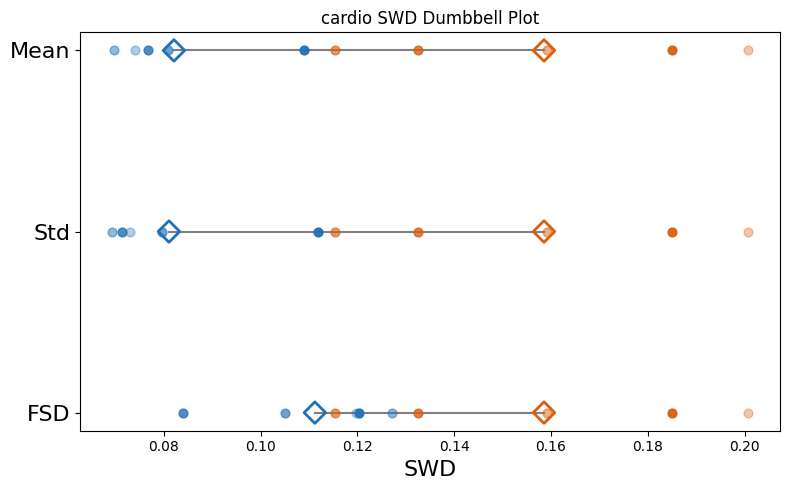

In [25]:
import matplotlib.pyplot as plt
import numpy as np

metric = "SWD"  

constraints = ["Mean", "Std", "FSD"] #, "LSC"
y_pos = np.arange(len(constraints))

baseline_vals = plot_df[plot_df["constraint"] == "DCE"][metric].values
baseline_mean = baseline_vals.mean()

baseline_color = "#d95f0e"
constrained_color = "#2171b5"
alphas = [0.35, 0.5, 0.65, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(8, 5))

for i, c in enumerate(constraints):
    constrained_vals = plot_df[plot_df["constraint"] == c][metric].values
    constrained_mean = constrained_vals.mean()

    # baseline 5
    for j, val in enumerate(baseline_vals):
        ax.scatter(
            val,
            i,
            color=baseline_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    # constrained 5
    for j, val in enumerate(constrained_vals):
        ax.scatter(
            val,
            i,
            color=constrained_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    ax.plot(
        [baseline_mean, constrained_mean],
        [i, i],
        color="gray",
        linewidth=1.5,
        zorder=2
    )

    ax.scatter(
        baseline_mean, i,
        facecolors="none",
        edgecolors=baseline_color,
        s=120, marker="D", linewidths=2, zorder=5
    )
    ax.scatter(
        constrained_mean, i,
        facecolors="none",
        edgecolors=constrained_color,
        s=120, marker="D", linewidths=2, zorder=5
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(constraints,fontsize=16)
ax.invert_yaxis()

ax.set_xlabel(metric,fontsize=16)
# ax.set_ylabel("Constraint")
ax.set_title(f"{dataset_name} {metric} Dumbbell Plot")

plt.tight_layout()
plt.show()

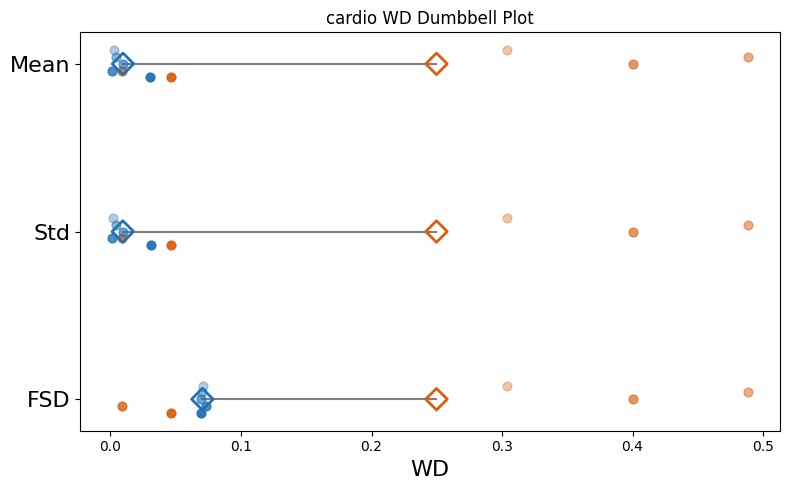

In [26]:
import matplotlib.pyplot as plt
import numpy as np

metric = "WD"  

constraints = ["Mean", "Std", "FSD"] #, "LSC"
y_pos = np.arange(len(constraints))

baseline_vals = plot_df[plot_df["constraint"] == "DCE"][metric].values
baseline_mean = baseline_vals.mean()

baseline_color = "#d95f0e"
constrained_color = "#2171b5"
alphas = [0.35, 0.5, 0.65, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(8, 5))

for i, c in enumerate(constraints):
    constrained_vals = plot_df[plot_df["constraint"] == c][metric].values
    constrained_mean = constrained_vals.mean()

    offsets = np.array([-0.08, -0.04, 0.0, 0.04, 0.08])
    for j, val in enumerate(baseline_vals):
        ax.scatter(
            val,
            i + offsets[j],
            color=baseline_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    for j, val in enumerate(constrained_vals):
        ax.scatter(
            val,
            i + offsets[j],
            color=constrained_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    ax.plot(
        [baseline_mean, constrained_mean],
        [i, i],
        color="gray",
        linewidth=1.5,
        zorder=2
    )

    ax.scatter(
        baseline_mean, i,
        facecolors="none",
        edgecolors=baseline_color,
        s=120, marker="D", linewidths=2, zorder=5
    )
    ax.scatter(
        constrained_mean, i,
        facecolors="none",
        edgecolors=constrained_color,
        s=120, marker="D", linewidths=2, zorder=5
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(constraints,fontsize=16)
ax.invert_yaxis()  

ax.set_xlabel(metric,fontsize=16)
# ax.set_ylabel("Constraint")
ax.set_title(f"{dataset_name} {metric} Dumbbell Plot")

plt.tight_layout()
plt.show()

# mean

In [27]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    weight_col = next(col for col in df.columns if "weight" in col)
    weight_mean = round(df[weight_col].mean(), 6)
    result_list.append([sheet, weight_mean])

print("=== Result DataFrame ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Weight_Mean"])
print(result_df)

overall_mean = round(result_df["Weight_Mean"].mean(), 6)
overall_std = round(result_df["Weight_Mean"].std(), 6)
print("\n=== Overall Statistics ===")
print(f"Mean of 5 Weight Means: {overall_mean}")
print(f"Std of 5 Weight Means: {overall_std}")

=== Result DataFrame ===
    Sheet_Name  Weight_Mean
0  DCE_Seed_40    75.443728
1  DCE_Seed_41    76.095428
2  DCE_Seed_42    73.312277
3  DCE_Seed_43    74.299150
4  DCE_Seed_44    74.625581

=== Overall Statistics ===
Mean of 5 Weight Means: 74.755233
Std of 5 Weight Means: 1.069707


In [28]:
baseline_means = result_df["Weight_Mean"].tolist()
baseline_overall_mean = overall_mean

In [29]:
file_path = os.path.join(data_dir, f"{dataset_name}_MeanConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    weight_col = next(col for col in df.columns if "weight" in col)
    weight_mean = round(df[weight_col].mean(), 6)
    result_list.append([sheet, weight_mean])

print("=== Result DataFrame ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Weight_Mean"])
print(result_df)

overall_mean = round(result_df["Weight_Mean"].mean(), 6)
overall_std = round(result_df["Weight_Mean"].std(), 6)
print("\n=== Overall Statistics ===")
print(f"Mean of 5 Weight Means: {overall_mean}")
print(f"Std of 5 Weight Means: {overall_std}")

=== Result DataFrame ===
     Sheet_Name  Weight_Mean
0  Mean_Seed_40    76.117498
1  Mean_Seed_41    78.598592
2  Mean_Seed_42    74.730837
3  Mean_Seed_43    74.887741
4  Mean_Seed_44    75.488724

=== Overall Statistics ===
Mean of 5 Weight Means: 75.964678
Std of 5 Weight Means: 1.570792


In [30]:
meanconstraint_means = result_df["Weight_Mean"].tolist()
meanconstraint_overall_mean = overall_mean

[75.443728, 76.095428, 73.312277, 74.29915, 74.625581]
[76.117498, 78.598592, 74.730837, 74.887741, 75.488724]
75.9646784


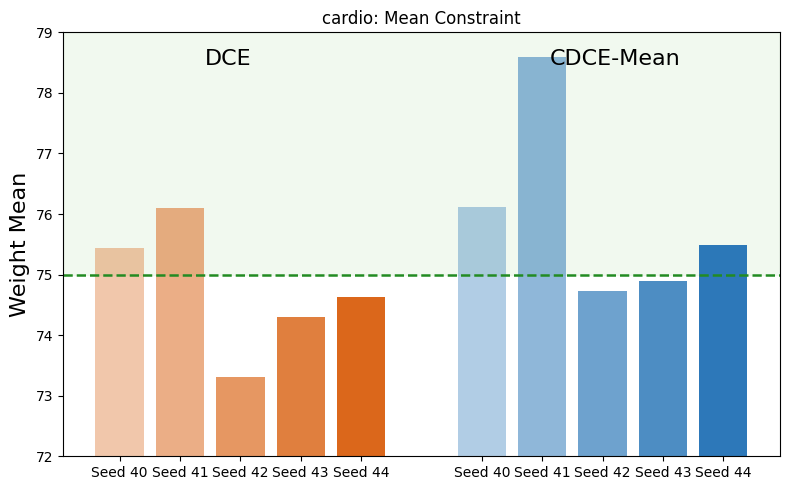

In [31]:
print(baseline_means)
print(meanconstraint_means)
t=np.mean(meanconstraint_means)
print(t)
x_base = np.arange(5)
x_cons = np.arange(5) + 6

fig, ax = plt.subplots(figsize=(8, 5))

for i, val in enumerate(baseline_means):
    ax.bar(x_base[i], val, color=baseline_color, alpha=alphas[i], width=0.8)

for i, val in enumerate(meanconstraint_means):
    ax.bar(x_cons[i], val, color=constrained_color, alpha=alphas[i], width=0.8)

target_lower = 75
ax.axhspan(target_lower, 79, color="#d9f0d3", alpha=0.35, zorder=0)
ax.axhline(target_lower, color="forestgreen", linestyle="--", linewidth=1.8)

ax.set_xticks(list(x_base) + list(x_cons))
ax.set_xticklabels(
    ["Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44",
     "Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44"],
    rotation=0
)

ax.set_ylim(72, 79)

# ax.text(np.mean(x_base), 78.9, "DCE", ha="center", va="top")
# ax.text(np.mean(x_cons), 78.9, "Mean-Constrained", ha="center", va="top")

ax.text(
    0.23, 0.96, "DCE",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.text(
    0.77, 0.96, "CDCE-Mean",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)


ax.set_ylabel("Weight Mean",fontsize=16)
ax.set_title(f"{dataset_name}: Mean Constraint")
plt.tight_layout()
plt.show()

# std

=== Result DataFrame (Sheet Name & ap_lo Std) ===
    Sheet_Name  ap_lo_Std
0  DCE_Seed_40  73.891294
1  DCE_Seed_41  75.864555
2  DCE_Seed_42  76.590394
3  DCE_Seed_43  71.995079
4  DCE_Seed_44  85.090039

=== Overall Statistics of ap_lo Stds ===
Mean of 5 ap_lo Stds: 76.686272
Std of 5 ap_lo Stds: 5.028094
=== Result DataFrame (Sheet Name & ap_lo Std) ===
    Sheet_Name  ap_lo_Std
0  Std_Seed_40  35.729141
1  Std_Seed_41  36.226207
2  Std_Seed_42  38.282214
3  Std_Seed_43  33.853364
4  Std_Seed_44  43.962788

=== Overall Statistics of ap_lo Stds ===
Mean of 5 ap_lo Stds: 37.610743
Std of 5 ap_lo Stds: 3.885055
[73.891294, 75.864555, 76.590394, 71.995079, 85.090039]
[35.729141, 36.226207, 38.282214, 33.853364, 43.962788]


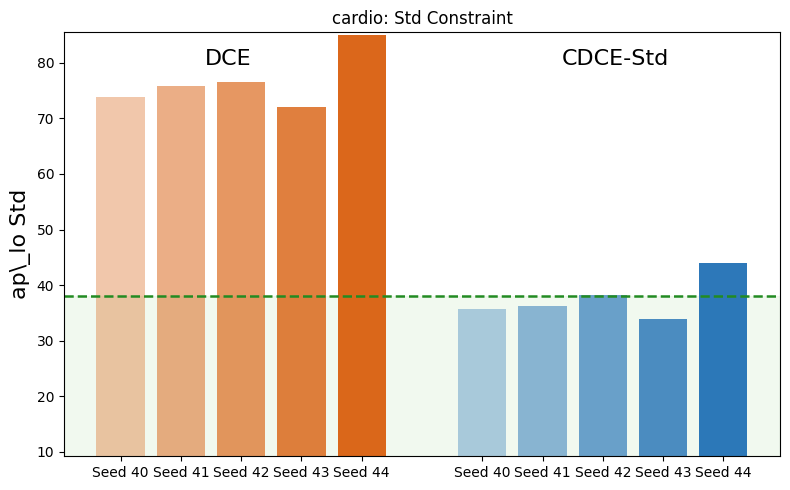

In [32]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ap_lo_col = next(col for col in df.columns if "ap_lo" in col)
    ap_lo_std = round(df[ap_lo_col].dropna().std(), 6)
    result_list.append([sheet, ap_lo_std])

print("=== Result DataFrame (Sheet Name & ap_lo Std) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "ap_lo_Std"])
print(result_df)

ap_lo_std_mean = round(result_df["ap_lo_Std"].mean(), 6)
ap_lo_std_self_std = round(result_df["ap_lo_Std"].std(), 6)

print("\n=== Overall Statistics of ap_lo Stds ===")
print(f"Mean of 5 ap_lo Stds: {ap_lo_std_mean}")
print(f"Std of 5 ap_lo Stds: {ap_lo_std_self_std}")

baseline_stds = result_df["ap_lo_Std"].tolist()
baseline_std_mean = ap_lo_std_mean

file_path = os.path.join(data_dir, f"{dataset_name}_StdConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ap_lo_col = next(col for col in df.columns if "ap_lo" in col)
    ap_lo_std = round(df[ap_lo_col].dropna().std(), 6)
    result_list.append([sheet, ap_lo_std])

print("=== Result DataFrame (Sheet Name & ap_lo Std) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "ap_lo_Std"])
print(result_df)

ap_lo_std_mean = round(result_df["ap_lo_Std"].mean(), 6)
ap_lo_std_self_std = round(result_df["ap_lo_Std"].std(), 6)

print("\n=== Overall Statistics of ap_lo Stds ===")
print(f"Mean of 5 ap_lo Stds: {ap_lo_std_mean}")
print(f"Std of 5 ap_lo Stds: {ap_lo_std_self_std}")

stdconstraint_stds = result_df["ap_lo_Std"].tolist()
stdconstraint_std_mean = ap_lo_std_mean

print(baseline_stds)
print(stdconstraint_stds)

x_base = np.arange(5)
x_cons = np.arange(5) + 6

fig, ax = plt.subplots(figsize=(8, 5))

for i, val in enumerate(baseline_stds):
    ax.bar(x_base[i], val, color=baseline_color, alpha=alphas[i], width=0.8)

for i, val in enumerate(stdconstraint_stds):
    ax.bar(x_cons[i], val, color=constrained_color, alpha=alphas[i], width=0.8)

target_upper = 38
ax.axhspan(0, target_upper, color="#d9f0d3", alpha=0.35, zorder=0)
ax.axhline(target_upper, color="forestgreen", linestyle="--", linewidth=1.8)

ax.set_xticks(list(x_base) + list(x_cons))
ax.set_xticklabels(
    ["Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44",
     "Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44"],
    rotation=0
)

y_max = max(max(baseline_stds), max(stdconstraint_stds))
ax.set_ylim(min(9.2, min(min(baseline_stds), min(stdconstraint_stds)) - 0.2), y_max + 0.4)

ax.text(
    0.23, 0.96, "DCE",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.text(
    0.77, 0.96, "CDCE-Std",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.set_ylabel("ap\\_lo Std",fontsize=16)
ax.set_title(f"{dataset_name}: Std Constraint")
plt.tight_layout()
plt.show()

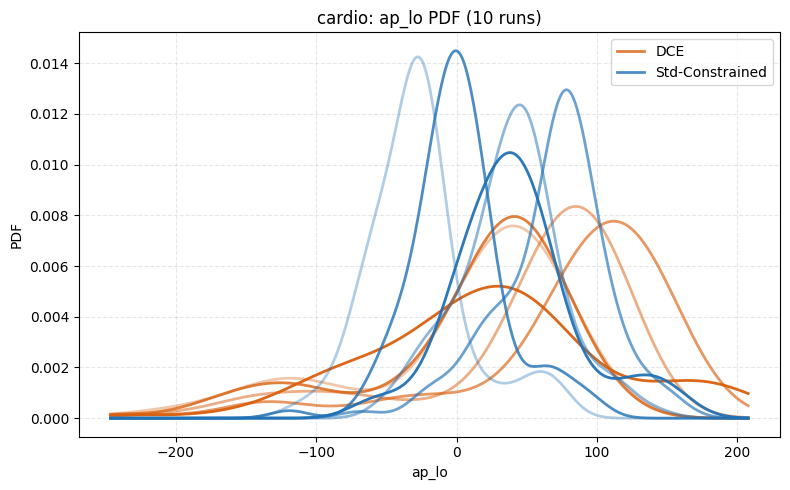

In [33]:
from scipy.stats import gaussian_kde

file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

baseline_data = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ap_lo_col = next(col for col in df.columns if "ap_lo" in col)
    baseline_data.append(df[ap_lo_col].dropna().values)

file_path = os.path.join(data_dir, f"{dataset_name}_StdConstraint.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

constrained_data = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ap_lo_col = next(col for col in df.columns if "ap_lo" in col)
    constrained_data.append(df[ap_lo_col].dropna().values)

all_values = np.concatenate(baseline_data + constrained_data)
x_grid = np.linspace(all_values.min(), all_values.max(), 500)

fig, ax = plt.subplots(figsize=(8, 5))

for i, values in enumerate(baseline_data):
    kde = gaussian_kde(values)
    y = kde(x_grid)
    ax.plot(x_grid, y, color=baseline_color, alpha=alphas[i], linewidth=2)

for i, values in enumerate(constrained_data):
    kde = gaussian_kde(values)
    y = kde(x_grid)
    ax.plot(x_grid, y, color=constrained_color, alpha=alphas[i], linewidth=2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=baseline_color, lw=2, alpha=0.8, label="DCE"),
    Line2D([0], [0], color=constrained_color, lw=2, alpha=0.8, label="Std-Constrained"),
]
ax.legend(handles=legend_elements)

ax.set_xlabel("ap_lo")
ax.set_ylabel("PDF")
ax.set_title(f"{dataset_name}: ap_lo PDF (10 runs)")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# lsc

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os, random, numpy as np, torch


def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)          
    np.random.seed(seed)       
    torch.manual_seed(seed)    
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed=42

df_heloc = pd.read_csv('data/cardio/cardio.csv',delimiter=';')
target_name='cardio'
df_X = df_heloc.iloc[:, 1:].copy()
df_X = df_X.drop(columns=[target_name]).copy()

df_y = df_heloc[target_name]

set_seed(seed)
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(X_train)

X_lin_train = X_train[["gluc"]].values.reshape(-1, 1)
y_lin_train = X_train["cholesterol"].values

lin_reg = LinearRegression()
lin_reg.fit(X_lin_train, y_lin_train)

y_pred_train = lin_reg.predict(X_lin_train)
mse_train = mean_squared_error(y_lin_train, y_pred_train)

coef = lin_reg.coef_[0]
intercept = lin_reg.intercept_
print(f"Linear model: cholesterol = {coef:.4f} * gluc + {intercept:.4f}")
print(f"MSE on training data: {mse_train:.4f}")

            age    gender    height    weight     ap_hi     ap_lo  \
47339  0.976378 -0.733764 -1.263899  0.404662  0.008508 -0.035487   
67456 -1.112790  1.362812 -0.286795 -0.291661  0.075918 -0.035487   
12308  0.673471  1.362812  1.178861  1.240251  0.143329  0.015024   
32557  1.579762  1.362812  1.056723  0.126133 -0.058902 -0.075896   
664    0.330473 -0.733764 -0.531071 -0.987985 -0.058902 -0.085998   
...         ...       ...       ...       ...       ...       ...   
37194 -1.402739  1.362812  0.690309  0.056501  0.143329 -0.085998   
6265   1.516184  1.362812 -0.286795 -0.082764  0.210739 -0.035487   
54886  1.670067 -0.733764  0.568171 -0.013132 -0.058902 -0.085998   
860   -0.501307 -0.733764  0.323895 -0.291661 -0.058902 -0.085998   
15795 -1.761935  1.362812  1.545274 -0.709455 -0.058902 -0.085998   

       cholesterol      gluc     smoke      alco    active  
47339     0.932855 -0.394629 -0.312077 -0.240874  0.494101  
67456    -0.539189 -0.394629 -0.312077 -0.240874 

In [35]:
import pandas as pd
import numpy as np
import os, random, torch

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed = 42
set_seed(seed)

# =========================
# 1. read data
# =========================
df_cardio = pd.read_csv("data/cardio/cardio.csv", delimiter=";")

target_name = "cardio"

# drop id, keep input features
df_X = df_cardio.iloc[:, 1:].copy()
df_X = df_X.drop(columns=[target_name]).copy()

df_y = df_cardio[target_name]

# =========================
# 2. split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=seed
)

# =========================
# 3. normalize by training stats
# =========================
std = X_train.std()
mean = X_train.mean()

# avoid zero std
std = std.replace(0, 1)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Normalized X_train:")
print(X_train.head())
print()

# =========================
# 4. pairwise linear regression
# =========================
results = []
features = X_train.columns.tolist()

for x_col in features:
    for y_col in features:
        if x_col == y_col:
            continue

        X_lin_train = X_train[[x_col]].values.reshape(-1, 1)
        y_lin_train = X_train[y_col].values

        lin_reg = LinearRegression()
        lin_reg.fit(X_lin_train, y_lin_train)

        y_pred_train = lin_reg.predict(X_lin_train)

        coef = lin_reg.coef_[0]
        intercept = lin_reg.intercept_
        mse_train = mean_squared_error(y_lin_train, y_pred_train)
        r2_train = r2_score(y_lin_train, y_pred_train)

        linear_model_str = f"{y_col} = {coef:.4f} * {x_col} + {intercept:.4f}"

        results.append({
            "X_feature": x_col,
            "Y_feature": y_col,
            "coef": coef,
            "intercept": intercept,
            "MSE": mse_train,
            "R2": r2_train,
            "Linear_model": linear_model_str
        })

# =========================
# 5. make ranking table
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

# round for better display
results_df["coef"] = results_df["coef"].round(4)
results_df["intercept"] = results_df["intercept"].round(4)
results_df["MSE"] = results_df["MSE"].round(4)
results_df["R2"] = results_df["R2"].round(4)

# =========================
# 6. print table
# =========================
print("Top 30 strongest linear relationships in Cardio:")
print(results_df.head(30).to_string(index=False))

# =========================
# 7. print best pair
# =========================
best_row = results_df.iloc[0]
print("\nBest pair:")
print(best_row["Linear_model"])
print(f"MSE on training data: {best_row['MSE']:.4f}")
print(f"R^2 on training data: {best_row['R2']:.4f}")

# =========================
# 8. save table
# =========================
# results_df.to_excel("cardio_pairwise_linear_ranking.xlsx", index=False)
print("\nSaved to: cardio_pairwise_linear_ranking.xlsx")

Normalized X_train:
            age    gender    height    weight     ap_hi     ap_lo  \
47339  0.976378 -0.733764 -1.263899  0.404662  0.008508 -0.035487   
67456 -1.112790  1.362812 -0.286795 -0.291661  0.075918 -0.035487   
12308  0.673471  1.362812  1.178861  1.240251  0.143329  0.015024   
32557  1.579762  1.362812  1.056723  0.126133 -0.058902 -0.075896   
664    0.330473 -0.733764 -0.531071 -0.987985 -0.058902 -0.085998   

       cholesterol      gluc     smoke      alco    active  
47339     0.932855 -0.394629 -0.312077 -0.240874  0.494101  
67456    -0.539189 -0.394629 -0.312077 -0.240874 -2.023841  
12308    -0.539189 -0.394629 -0.312077 -0.240874  0.494101  
32557    -0.539189 -0.394629 -0.312077 -0.240874  0.494101  
664      -0.539189 -0.394629 -0.312077 -0.240874  0.494101  

Top 30 strongest linear relationships in Cardio:
 Rank   X_feature   Y_feature    coef  intercept    MSE     R2                            Linear_model
    1      height      gender  0.4994        0

In [36]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    chol_col = next(col for col in df.columns if "cholesterol" in col)
    gluc_col = next(col for col in df.columns if "gluc" in col)
    
    df_clean = df[[chol_col, gluc_col]].dropna()
    gluc_scaled = (df_clean[gluc_col] - mean["gluc"]) / std["gluc"]
    chol_scaled = (df_clean[chol_col] - mean["cholesterol"]) / std["cholesterol"]
    
    y_true = chol_scaled 
    y_pred = 0.4557 * gluc_scaled  
    mse = round(mean_squared_error(y_true, y_pred), 6)  
    
    result_list.append([sheet, mse])

print("=== Result DataFrame (Sheet Name & Model MSE) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Model_MSE"])
print(result_df)

mse_mean = round(result_df["Model_MSE"].mean(), 6)
mse_self_std = round(result_df["Model_MSE"].std(), 6)

print("\n=== Overall Statistics of Model MSE ===")
print(f"Mean of 5 Sheet MSEs: {mse_mean}")
print(f"Std of 5 Sheet MSEs: {mse_self_std}")

=== Result DataFrame (Sheet Name & Model MSE) ===
    Sheet_Name  Model_MSE
0  DCE_Seed_40   0.974007
1  DCE_Seed_41   0.978529
2  DCE_Seed_42   1.020593
3  DCE_Seed_43   1.007909
4  DCE_Seed_44   0.853765

=== Overall Statistics of Model MSE ===
Mean of 5 Sheet MSEs: 0.966961
Std of 5 Sheet MSEs: 0.066238


In [37]:
file_path = os.path.join(data_dir, f"{dataset_name}_LSCConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    chol_col = next(col for col in df.columns if "cholesterol" in col)
    gluc_col = next(col for col in df.columns if "gluc" in col)
    
    df_clean = df[[chol_col, gluc_col]].dropna()
    gluc_scaled = (df_clean[gluc_col] - mean["gluc"]) / std["gluc"]
    chol_scaled = (df_clean[chol_col] - mean["cholesterol"]) / std["cholesterol"]
    
    y_true = chol_scaled 
    y_pred = 0.4557 * gluc_scaled  
    mse = round(mean_squared_error(y_true, y_pred), 6)  
    
    result_list.append([sheet, mse])

print("=== Result DataFrame (Sheet Name & Model MSE) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Model_MSE"])
print(result_df)

mse_mean = round(result_df["Model_MSE"].mean(), 6)
mse_self_std = round(result_df["Model_MSE"].std(), 6)

print("\n=== Overall Statistics of Model MSE ===")
print(f"Mean of 5 Sheet MSEs: {mse_mean}")
print(f"Std of 5 Sheet MSEs: {mse_self_std}")

=== Result DataFrame (Sheet Name & Model MSE) ===
    Sheet_Name  Model_MSE
0  LSC_Seed_40   0.316466
1  LSC_Seed_41   0.315905
2  LSC_Seed_42   0.315670
3  LSC_Seed_43   0.316416
4  LSC_Seed_44   0.316505

=== Overall Statistics of Model MSE ===
Mean of 5 Sheet MSEs: 0.316192
Std of 5 Sheet MSEs: 0.00038


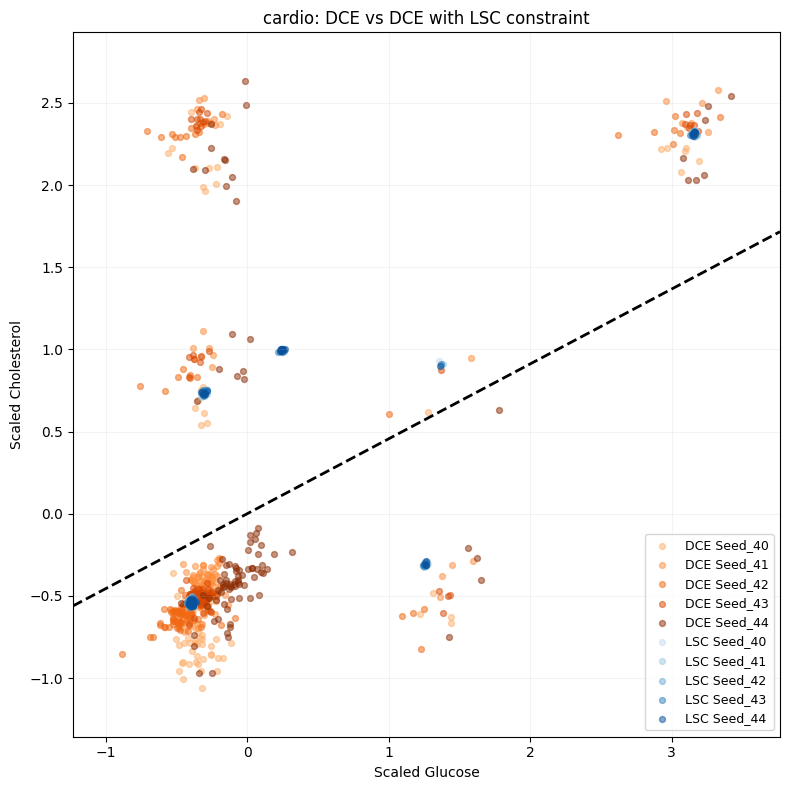

In [38]:
file_path_dce = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
file_path_lsc = os.path.join(data_dir, f"{dataset_name}_LSCConstraint.xlsx")

xl_dce = pd.ExcelFile(file_path_dce, engine="openpyxl")
xl_lsc = pd.ExcelFile(file_path_lsc, engine="openpyxl")

target_sheets_dce = xl_dce.sheet_names[:5]
target_sheets_lsc = xl_lsc.sheet_names[:5]

color_list_dce = ["#fdae6b", "#fd8d3c", "#f16913", "#d94801", "#8c2d04"]
color_list_lsc = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]

fig, ax = plt.subplots(figsize=(8, 8))

all_x = []
all_y = []

# DCE: orange
for i, sheet in enumerate(target_sheets_dce):
    df = pd.read_excel(file_path_dce, sheet_name=sheet, engine="openpyxl")
    chol_col = next(col for col in df.columns if "cholesterol" in col)
    gluc_col = next(col for col in df.columns if "gluc" in col)

    df_clean = df[[chol_col, gluc_col]].dropna()
    gluc_scaled = (df_clean[gluc_col] - mean["gluc"]) / std["gluc"]
    chol_scaled = (df_clean[chol_col] - mean["cholesterol"]) / std["cholesterol"]

    x = gluc_scaled.to_numpy()
    y = chol_scaled.to_numpy()

    all_x.append(x)
    all_y.append(y)

    ax.scatter(
        x, y,
        s=18,
        alpha=0.50,
        color=color_list_dce[i],
        label=sheet.replace("DCE_", "DCE ")
    )

# LSC: blue
for i, sheet in enumerate(target_sheets_lsc):
    df = pd.read_excel(file_path_lsc, sheet_name=sheet, engine="openpyxl")
    chol_col = next(col for col in df.columns if "cholesterol" in col)
    gluc_col = next(col for col in df.columns if "gluc" in col)

    df_clean = df[[chol_col, gluc_col]].dropna()
    gluc_scaled = (df_clean[gluc_col] - mean["gluc"]) / std["gluc"]
    chol_scaled = (df_clean[chol_col] - mean["cholesterol"]) / std["cholesterol"]

    x = gluc_scaled.to_numpy()
    y = chol_scaled.to_numpy()

    all_x.append(x)
    all_y.append(y)

    ax.scatter(
        x, y,
        s=18,
        alpha=0.50,
        color=color_list_lsc[i],
        label=sheet.replace("LSC_", "LSC ")
    )

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

x_range = x_max - x_min
y_range = y_max - y_min

x_left = x_min - 0.08 * x_range
x_right = x_max + 0.08 * x_range
y_low = y_min - 0.08 * y_range
y_high = y_max + 0.08 * y_range

ax.set_xlim(x_left, x_right)
ax.set_ylim(y_low, y_high)

line_x = np.linspace(x_left, x_right, 300)
line_y = 0.4557 * line_x + 0.0000
ax.plot(
    line_x,
    line_y,
    linestyle="--",
    linewidth=2,
    color="black"
)

ax.set_xlabel("Scaled Glucose")
ax.set_ylabel("Scaled Cholesterol")
ax.set_title(f"{dataset_name}: DCE vs DCE with LSC constraint")
ax.grid(alpha=0.15)
ax.legend(frameon=True, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

# fsd

In [2]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch
import numpy as np
# X_fact= pd.read_csv('cardio_explained_samples.csv')
X_fact = pd.read_csv(os.path.join("cardio", "cardio_explained_samples.csv"))

file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []

for sheet_name in target_sheets:
        
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    
    fact_ExternalRiskEstimate = X_fact["weight"]
    cf_ExternalRiskEstimate = X_cf["weight"]

    result_cf = FSDConstraintTorch.check_FSD(
        fact_ExternalRiskEstimate, cf_ExternalRiskEstimate,
        direction=-1  
    )   
    result_list.append({
        "Sheet_Name": sheet_name,
        "Violation_Count": len(result_cf["violations"])
    })

result_df = pd.DataFrame(result_list)
print("\n=== Result DataFrame (Sheet Name & Violation Count) ===")
print(result_df)

violation_counts = result_df["Violation_Count"]
mean_violation = np.mean(violation_counts)  
std_violation = np.std(violation_counts, ddof=1) 

print("\n=== Overall Statistics of Violation Count ===")
print(f"Mean of 5 Sheet Violation Counts : {mean_violation:.6f}")
print(f"Std of 5 Sheet Violation Counts : {std_violation:.6f}")


=== Result DataFrame (Sheet Name & Violation Count) ===
    Sheet_Name  Violation_Count
0  DCE_Seed_40               81
1  DCE_Seed_41              111
2  DCE_Seed_42                2
3  DCE_Seed_43                3
4  DCE_Seed_44               42

=== Overall Statistics of Violation Count ===
Mean of 5 Sheet Violation Counts : 47.800000
Std of 5 Sheet Violation Counts : 48.048933


In [5]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch
X_fact = pd.read_csv(os.path.join("cardio", "cardio_explained_samples.csv"))

file_path = os.path.join(data_dir, f"{dataset_name}_FSDConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []

for sheet_name in target_sheets:
        
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    
    fact_ExternalRiskEstimate = X_fact["weight"]
    cf_ExternalRiskEstimate = X_cf["weight"]

    result_cf = FSDConstraintTorch.check_FSD(
        fact_ExternalRiskEstimate, cf_ExternalRiskEstimate,
        direction=-1   
    )   
    result_list.append({
        "Sheet_Name": sheet_name,
        "Violation_Count": len(result_cf["violations"])
    })

result_df = pd.DataFrame(result_list)
print("\n=== Result DataFrame (Sheet Name & Violation Count) ===")
print(result_df)

violation_counts = result_df["Violation_Count"]
mean_violation = np.mean(violation_counts)  
std_violation = np.std(violation_counts, ddof=1)  

print("\n=== Overall Statistics of Violation Count ===")
print(f"Mean of 5 Sheet Violation Counts : {mean_violation:.6f}")
print(f"Std of 5 Sheet Violation Counts : {std_violation:.6f}")


=== Result DataFrame (Sheet Name & Violation Count) ===
    Sheet_Name  Violation_Count
0  FSD_Seed_40                0
1  FSD_Seed_41                1
2  FSD_Seed_42                2
3  FSD_Seed_43                6
4  FSD_Seed_44                2

=== Overall Statistics of Violation Count ===
Mean of 5 Sheet Violation Counts : 2.200000
Std of 5 Sheet Violation Counts : 2.280351


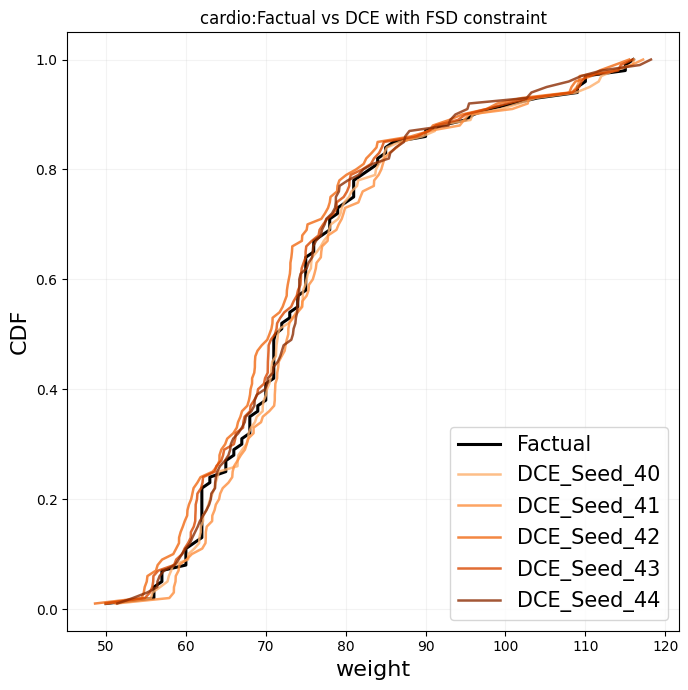

In [8]:
import matplotlib.pyplot as plt

X_fact = pd.read_csv(os.path.join("cardio", "cardio_explained_samples.csv"))

fact_weight = X_fact["weight"].dropna().to_numpy()
fact_weight_sorted = np.sort(fact_weight)
fact_cdf = np.arange(1, len(fact_weight_sorted) + 1) / len(fact_weight_sorted)

file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

orange_colors = ["#fdae6b", "#fd8d3c", "#f16913", "#d94801", "#8c2d04"]

plt.figure(figsize=(7, 7))

plt.plot(
    fact_weight_sorted,
    fact_cdf,
    color="black",
    linewidth=2.2,
    label="Factual"
)

for i, sheet_name in enumerate(target_sheets):
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    cf_weight = X_cf["weight"].dropna().to_numpy()
    cf_weight_sorted = np.sort(cf_weight)
    cf_cdf = np.arange(1, len(cf_weight_sorted) + 1) / len(cf_weight_sorted)

    seed_label = sheet_name

    plt.plot(
        cf_weight_sorted,
        cf_cdf,
        color=orange_colors[i],
        linewidth=1.8,
        alpha=0.8,
        label=seed_label
    )

plt.xlabel("weight", fontsize=16)
plt.ylabel("CDF", fontsize=16)
plt.title(f"{dataset_name}:Factual vs DCE with FSD constraint")
plt.grid(alpha=0.15)
plt.legend(frameon=True,loc="lower right", fontsize=15)
plt.tight_layout()
plt.show()

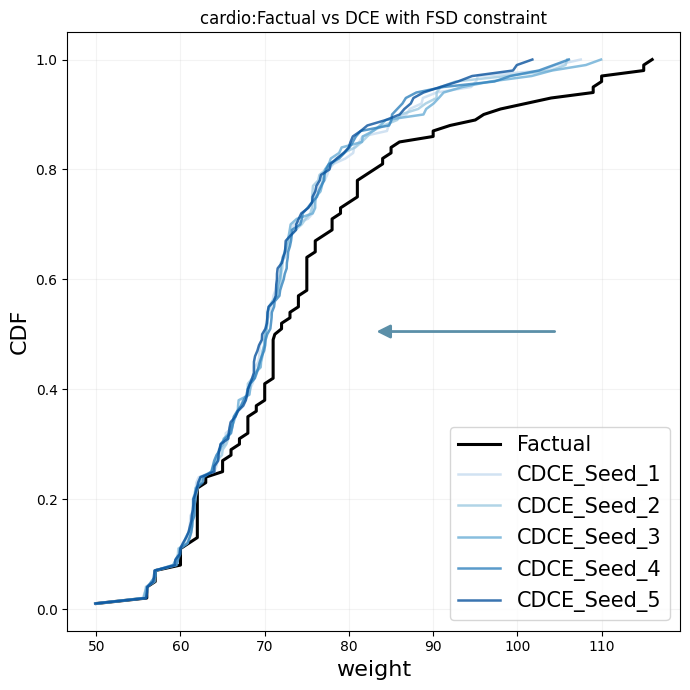

In [10]:
X_fact = pd.read_csv(os.path.join("cardio", "cardio_explained_samples.csv"))

fact_weight = X_fact["weight"].dropna().to_numpy()
fact_weight_sorted = np.sort(fact_weight)
fact_cdf = np.arange(1, len(fact_weight_sorted) + 1) / len(fact_weight_sorted)

file_path = os.path.join(data_dir, f"{dataset_name}_FSDConstraint.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

blue_colors = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]

plt.figure(figsize=(7, 7))

plt.plot(
    fact_weight_sorted,
    fact_cdf,
    color="black",
    linewidth=2.2,
    label="Factual"
)

for i, sheet_name in enumerate(target_sheets):
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    cf_weight = X_cf["weight"].dropna().to_numpy()
    cf_weight_sorted = np.sort(cf_weight)
    cf_cdf = np.arange(1, len(cf_weight_sorted) + 1) / len(cf_weight_sorted)

    # seed_label = sheet_name.replace("LSC_", "Seed ")

    plt.plot(
        cf_weight_sorted,
        cf_cdf,
        color=blue_colors[i],
        linewidth=1.8,
        alpha=0.8,
        label=f"CDCE_Seed_{i + 1}" 
    )

ax = plt.gca()

ax.annotate(
    '',
    xy=(0.5, 0.5),      
    xytext=(0.8, 0.5),  
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=6,
        mutation_scale=20,
        color="#5B8FA8",
        lw=2
    )
)

plt.xlabel("weight", fontsize=16)
plt.ylabel("CDF", fontsize=16)
plt.title(f"{dataset_name}:Factual vs DCE with FSD constraint")
plt.grid(alpha=0.15)
plt.legend(frameon=True,loc="lower right", fontsize=15)
plt.tight_layout()
plt.show()